In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.feature_extraction import DictVectorizer


In [41]:
df = pd.read_csv('churn.csv')

df.columns = df.columns.str.lower().str.replace(' ', '_')


categorical_columns = [
    column for column in df.columns if df[column].dtype == "str"
]

for col in categorical_columns:
    df[col] = df[col].str.lower().str.replace(" ", "_")

df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

df.churn = (df.churn == 'yes').astype(int)

df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-vhveg,female,0,yes,no,1,no,no_phone_service,dsl,no,...,no,no,no,no,month-to-month,yes,electronic_check,29.85,29.85,0
1,5575-gnvde,male,0,no,no,34,yes,no,dsl,yes,...,yes,no,no,no,one_year,no,mailed_check,56.95,1889.50,0
2,3668-qpybk,male,0,no,no,2,yes,no,dsl,yes,...,no,no,no,no,month-to-month,yes,mailed_check,53.85,108.15,1
3,7795-cfocw,male,0,no,no,45,no,no_phone_service,dsl,yes,...,yes,yes,no,no,one_year,no,bank_transfer_(automatic),42.30,1840.75,0
4,9237-hqitu,female,0,no,no,2,yes,no,fiber_optic,no,...,no,no,no,no,month-to-month,yes,electronic_check,70.70,151.65,1


In [42]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_val.churn.values

del df_train['churn']
del df_val['churn']
del df_test['churn']


In [43]:
numerical = [
    'tenure', 
    'monthlycharges',
    'totalcharges',
]

categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [44]:
dv = DictVectorizer(sparse=False)


train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

In [45]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalt

In [46]:
y_pred = model.predict_proba(X_val)[:, 1]

churn_decision = (y_pred >= 0.5)
(y_val == churn_decision).mean()

np.float64(0.8055358410220014)

In [47]:
from sklearn.metrics import accuracy_score

In [48]:
accuracy_score(y_val, churn_decision)

0.8055358410220014

### Try in different Tresholds

In [49]:
tresholds = np.linspace(0, 1, 21)

scores = []

for t in tresholds:
    churn_decision = (y_pred >= t)
    score = (y_val == churn_decision).mean()
    scores.append((t, score))
    print("{} - {}".format(t.round(2), score))

0.0 - 0.2739531582682754
0.05 - 0.5081618168914124
0.1 - 0.6053938963804116
0.15 - 0.6635911994322214
0.2 - 0.7047551454932577
0.25 - 0.7381121362668559
0.3 - 0.759403832505323
0.35 - 0.7665010645848119
0.4 - 0.7806955287437899
0.45 - 0.7927608232789212
0.5 - 0.8055358410220014
0.55 - 0.8041163946061036
0.6 - 0.7998580553584103
0.65 - 0.78708303761533
0.7 - 0.765791341376863
0.75 - 0.7423704755145494
0.8 - 0.7288857345635202
0.85 - 0.7260468417317246
0.9 - 0.7260468417317246
0.95 - 0.7260468417317246
1.0 - 0.7260468417317246


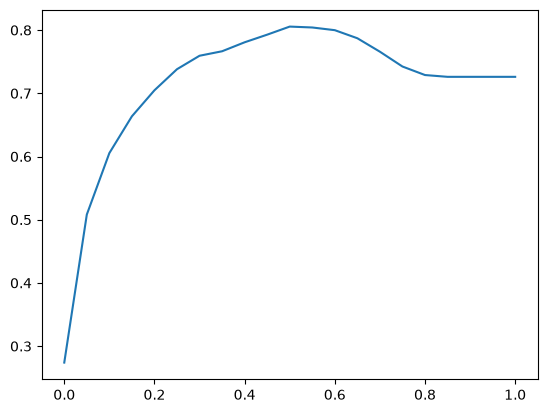

In [50]:
plt.plot(*zip(*scores))

### When tresholds is getting to 1 accuracy score is not changing it is appoximately 72 % which tells us even if we don't use any model we can get 72 - 73 % accuracy our model gets 80 % we trained model only for 7 - 8 %

## Confusion Table

**`predict_positive` va `predict_negative` nima?**

- `predict_positive = (y_pred >= t)` — model ehtimolligi threshold (`t`)dan katta yoki teng bo'lgan customer'lar, ya'ni model **"bu customer churn qiladi"** deb bashorat qilgan yozuvlar (boolean massiv).
- `predict_negative = (y_pred < t)` — model ehtimolligi threshold'dan kichik bo'lganlar, ya'ni model **"bu customer churn qilmaydi"** deb bashorat qilganlar.

Bular hali "to'g'ri" yoki "noto'g'ri" ekanini bildirmaydi — faqat modelning qarorini ko'rsatadi. Haqiqiy natija bilan (`actual_positive` / `actual_negative`) solishtirilganda confusion matrix hujayralari kelib chiqadi:

- `tp` = haqiqatan churn, model ham churn dedi (to'g'ri)
- `fp` = aslida churn emas, lekin model churn dedi (xato — false alarm)
- `fn` = aslida churn, lekin model churn emas dedi (xato — o'tkazib yuborilgan)
- `tn` = aslida churn emas, model ham churn emas dedi (to'g'ri)

In [51]:
actual_positive = (y_val == 1) # churn
actual_negative = (y_val == 0) # not churn

t = 0.5

predict_positive = (y_pred >= t) # we predict that the customer will churn
predict_negative = (y_pred < t) # we predict that the customer will not churn

tp = (actual_positive & predict_positive).sum() # true positive
fp = (actual_negative & predict_positive).sum() # false positive
fn = (actual_positive & predict_negative).sum() # false negative
tn = (actual_negative & predict_negative).sum() # true negative

print(tp, fp, fn, tn)



212 100 174 923


In [52]:
confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])

## Precision va recall

In [53]:
p = tp / (tp + fp)
r = tp / (tp + fn)

**`precision` va `recall` nima?**

- `precision = tp / (tp + fp)` — model **churn deb bashorat qilgan** hammalar orasidan nechtasi haqiqatan ham churn qilgan. Ya'ni "model to'g'ri deb aytganlariga qanchalik ishonish mumkin".
  - Bizning holatda: `212 / (212 + 100) = 212 / 312 ≈ 0.68` — model churn deb belgilagan 100 tadan taxminan 68 tasi to'g'ri chiqadi.
- `recall = tp / (tp + fn)` — haqiqatda churn qilganlarning hammasi orasidan nechtasini model **topa oldi** (ushlab qoldi). Ya'ni "model haqiqiy churn'larni qancha qismini o'tkazib yubormadi".
  - Bizning holatda: `212 / (212 + 174) ≈ 0.55` — haqiqiy churn qilgan mijozlarning atigi 55%ini model to'g'ri aniqlay oldi, qolgan 45%i (`fn`) o'tkazib yuborilgan.

Farqi:
- **Precision past** bo'lsa — model ko'p **false alarm** (`fp`) beradi: churn qilmaydigan mijozga ham churn deb belgilaydi.
- **Recall past** bo'lsa — model ko'p haqiqiy churn'ni **o'tkazib yuboradi** (`fn`): aslida ketadigan mijozni "ketmaydi" deb noto'g'ri baholaydi.

Bu ikkisi odatda bir-biriga qarama-qarshi (trade-off): threshold `t`ni pasaytirsak — recall oshadi, lekin precision tushadi (chunki ko'proq mijozni "churn" deb belgilaymiz, demak xato positive'lar ham ko'payadi); threshold'ni oshirsak — aksincha.

Shu sabab faqat `accuracy`ga qarab bo'lmaydi: bizning datasetda churn qilmaydiganlar ko'p (class imbalance) bo'lgani uchun accuracy yuqori ko'rinishi mumkin, lekin model aynan churn qiladigan mijozlarni yaxshi topa olmasligi mumkin — buni faqat precision/recall orqali ko'ramiz.


## ROC Curves

In [54]:
tpr = tp / (tp + fn)
fpr = fp / (fp + tn)

tpr, fpr

(np.float64(0.5492227979274611), np.float64(0.09775171065493646))

**ROC curve nima va `tpr` / `fpr` nimani anglatadi?**

- `tpr = tp / (tp + fn)` — **True Positive Rate** (bu xuddi `recall` bilan bir xil formula!). Haqiqiy churn qilganlarning qanchasini model to'g'ri topdi.
  - Bizning holatda: `212 / (212 + 174) ≈ 0.55`.
- `fpr = fp / (fp + tn)` — **False Positive Rate**. Aslida churn qilmaydigan mijozlarning qanchasiga model noto'g'ri "churn qiladi" deb yorliq qo'ydi.
  - Bizning holatda: `100 / (100 + 923) ≈ 0.098` — churn qilmaydigan mijozlarning ~10%iga noto'g'ri alarm berilgan.

Hozircha bu ikkalasi faqat bitta threshold (`t = 0.5`) uchun hisoblangan — bu ROC curve'dagi bitta nuqta xolos.

**ROC curve** — threshold `t`ni 0dan 1gacha o'zgartirib, har bir `t` uchun `fpr`ni x-o'qqa, `tpr`ni y-o'qqa qo'yib chizilgan grafik:

- `t` past bo'lganda (masalan 0) — deyarli hammani "churn" deb bashorat qilamiz → `tpr` ham, `fpr` ham 1ga yaqin.
- `t` yuqori bo'lganda (masalan 1) — deyarli hech kimni "churn" demaymiz → `tpr` ham, `fpr` ham 0ga yaqin.
- Yaxshi model — egri chiziq chap yuqori burchakka (`fpr` past, `tpr` yuqori) qanchalik yaqin bo'lsa, shunchalik yaxshi (kam xato bilan ko'proq haqiqiy churn'ni topadi).
- Tasodifiy (random) model uchun ROC curve — diagonal chiziq (`tpr == fpr`), chunki tasodifiy bashorat qanday threshold bo'lishidan qat'iy nazar ikkalasini bir xil nisbatda oshiradi. Shu diagonal bizning modelni solishtirish uchun "baseline" bo'ladi — model shu chiziqdan qancha yuqorida bo'lsa, shuncha yaxshi.
- Egri chiziq ostidagi maydon (**AUC — Area Under Curve**) — butun ROC curve'ni bitta songa siqib, modelni umumiy baholash uchun ishlatiladi (1.0 — ideal, 0.5 — tasodifiy model).


In [55]:
scores = []

thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()
    
    scores.append((t, tp, fp, fn, tn))

In [56]:
columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
df_scores = pd.DataFrame(scores, columns=columns)

df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)

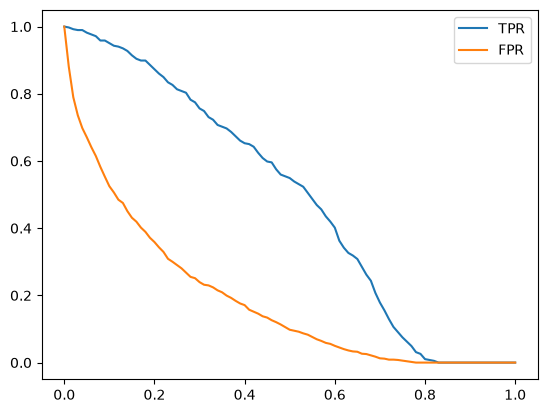

In [57]:
plt.plot(df_scores.threshold, df_scores['tpr'], label='TPR')
plt.plot(df_scores.threshold, df_scores['fpr'], label='FPR')
plt.legend()

## Random model

In [58]:
np.random.seed(1)

y_rand = np.random.uniform(0, 1, len(y_val))

((y_rand >= 0.5) == y_val).mean()

np.float64(0.5017743080198722)

In [59]:
def tpr_fpr_dataframe(y_val, y_pred):
    scores = []

    thresholds = np.linspace(0, 1, 101)

    for t in thresholds:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)

        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)

        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()

        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()

        scores.append((t, tp, fp, fn, tn))

    columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
    df_scores = pd.DataFrame(scores, columns=columns)

    df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
    df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)
    
    return df_scores

In [60]:
df_rand = tpr_fpr_dataframe(y_val, y_rand)

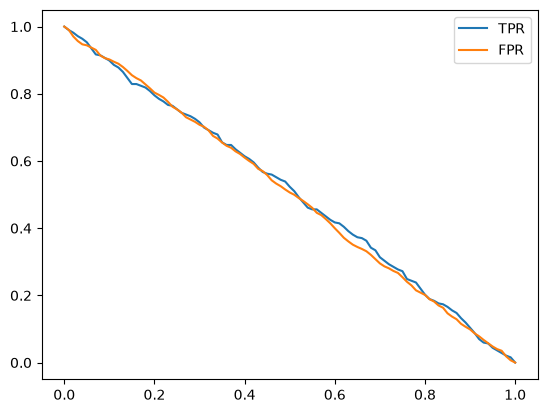

In [61]:
plt.plot(df_rand.threshold, df_rand['tpr'], label='TPR')
plt.plot(df_rand.threshold, df_rand['fpr'], label='FPR')
plt.legend()

**Random model nima uchun kerak?**

Bu — solishtirish uchun **baseline**. Model umuman hech narsa o'rganmagan, `y_val`ga aloqasi yo'q, faqat tasodifiy (0 dan 1 gacha) score chiqarayotgan bo'lsa nima bo'lishini ko'rsatadi (`y_rand = np.random.uniform(0, 1, len(y_val))`).

- `y_rand`ning haqiqiy `y_val` bilan hech qanday bog'liqligi yo'q, shuning uchun har qanday threshold `t` uchun **churn deb belgilanganlar orasida haqiqiy churn ulushi ham, haqiqiy no-churn ulushi ham bir xil nisbatda** bo'ladi.
- Natijada `tpr(t) ≈ fpr(t) ≈ (1 - t)` — ikkala chiziq deyarli bir xil, ustma-ust tushadi va chiziqli pasayadi. Aynan shu — oldingi ROC tushuntirishda aytilgan **diagonal chiziq**ning o'zi (`tpr == fpr`).
- Xulosa: agar bizning haqiqiy modelimizning TPR/FPR chizig'i shu random model chizig'idan uzoq (yuqorida) bo'lmasa, demak model haqiqatan ham foydali narsa o'rganmagan — tasodifdan farqi yo'q.

Eslatma: avval `y_rand`ni `np.random.randint(0, 1, ...)` bilan hosil qilgan edik — bu **doim 0** qaytaradi (`high=1` qamrab olinmaydi), ya'ni haqiqiy random emas edi. `np.random.uniform(0, 1, ...)`ga tuzatildi, chunki `y_pred` kabi threshold bilan solishtiriladigan **uzluksiz score** kerak, binary 0/1 emas.

## Ideal model

In [62]:
num_neg = (y_val == 0).sum()
num_pos = (y_val == 1).sum()

y_ideal = np.repeat([0, 1], [num_neg, num_pos])
y_ideal_pred = np.linspace(0, 1, len(y_val))

((y_ideal_pred >= 0.726) == y_ideal).mean()

np.float64(1.0)

In [63]:
df_ideal = tpr_fpr_dataframe(y_ideal, y_ideal_pred)
df_ideal[::10]

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,386,882,0,141,1.000000,0.862170
20,0.2,386,741,0,282,1.000000,0.724340
30,0.3,386,600,0,423,1.000000,0.586510
40,0.4,386,459,0,564,1.000000,0.448680
50,0.5,386,319,0,704,1.000000,0.311828
60,0.6,386,178,0,845,1.000000,0.173998
70,0.7,386,37,0,986,1.000000,0.036168
80,0.8,282,0,104,1023,0.730570,0.000000
90,0.9,141,0,245,1023,0.365285,0.000000


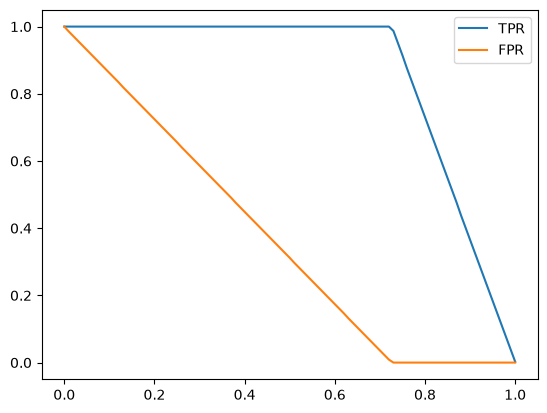

In [64]:
plt.plot(df_ideal.threshold, df_ideal['tpr'], label='TPR')
plt.plot(df_ideal.threshold, df_ideal['fpr'], label='FPR')
plt.legend()

**Ideal model nima va nega shunday quriladi?**

Bu — teskari baseline: modelning **eng yaxshi mumkin bo'lgan holati** — hech qanday xatosiz, `actual_positive` va `actual_negative`larni 100% aniqlikda ajrata oladigan "score" beradi.

- `num_neg`, `num_pos` — `y_val`dagi haqiqiy 0 va 1lar soni.
- `y_ideal = np.repeat([0, 1], [num_neg, num_pos])` — hammasi avval `0`lar, keyin `1`lar qilib tartiblangan "haqiqiy javoblar" (tartib muhim emas, chunki keyingi qatorda score ham xuddi shu tartibda beriladi).
- `y_ideal_pred = np.linspace(0, 1, len(y_val))` — 0dan 1gacha teng oshib boruvchi score'lar. Natijada eng past score'lar `y_ideal`dagi `0`larga, eng yuqori score'lar `1`larga to'g'ri keladi — ya'ni model **negativ va positivlarni mukammal tartibda ajratadi**.
- `0.726` threshold — bu `num_neg / len(y_val)` ga teng (taxminan), ya'ni aynan shu nuqtada barcha `0`lar va `1`lar bir-biridan **aniq chegara bilan** ajraladi, shuning uchun accuracy = 1.0 chiqadi.

**Ideal model'ning ROC (TPR/FPR) grafigi:**
- `t` biror chegaradan past bo'lguncha (ya'ni hamma narsani "positiv" deb belgilaguncha) `tpr = 1` bo'lib turadi va `fpr = 0` bo'lib turadi — chunki hali birorta ham haqiqiy negativ "positiv" deb noto'g'ri belgilanmagan.
- O'sha chegaradan keyin `tpr` va `fpr` ikkalasi ham keskin `0`ga tushadi.
- Grafikda bu ikki chiziq deyarli **90 daraja burchak** hosil qiladi (yuqorida tekis, keyin tik pastga) — bu ROC space'dagi **chap yuqori burchak (0, 1)** nuqtasiga to'g'ri keladi, ya'ni "eng yaxshi mumkin bo'lgan" nuqta.

**Uchala modelni solishtirish (Random vs Bizning model vs Ideal):**

| Model | TPR/FPR xatti-harakati | Ma'nosi |
|---|---|---|
| **Random** | `tpr ≈ fpr` — diagonal chiziq | Model hech narsa o'rganmagan, tasodifga teng |
| **Bizning model** | `tpr` chizig'i `fpr`dan sezilarli yuqorida, diagonal bilan ideal burchak orasida | Foydali, lekin mukammal emas — xatolari bor (`fp`, `fn`) |
| **Ideal** | `(0,1)` nuqtaga to'g'ri boradigan 90°-burchak | Nazariy maksimum — bundan yaxshisi bo'lmaydi |

Aynan shu uchtasini bitta grafikda solishtirish orqali (Random — pastki chegara, Ideal — yuqori chegara) bizning haqiqiy modelimiz shu ikkisi orasida qayerda turganini va u qanchalik "yaxshi" ekanini vizual baholash mumkin. Bu solishtiruvni bitta songa aylantirgani — aynan **AUC** (egri chiziq ostidagi maydon): Random uchun AUC = 0.5, Ideal uchun AUC = 1.0, bizning modelimiz esa shu oralikda joylashadi.

## AUC

In [ ]:
from sklearn.metrics import auc

auc(df_scores.fpr, df_scores.tpr)

In [ ]:
auc(df_ideal.fpr, df_ideal.tpr)

In [ ]:
auc(df_rand.fpr, df_rand.tpr)

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_val, y_pred)

**AUC (Area Under Curve) nima?**

AUC — ROC curve ostida qolgan maydon. U butun ROC grafigini (barcha threshold'lardagi TPR/FPR'larni) **bitta songa** siqib, modelni umumiy baholash imkonini beradi.

- `auc(df_scores.fpr, df_scores.tpr)` — bizning haqiqiy modelimizning ROC curve'i ostidagi maydonni **trapetsiya usuli** bilan hisoblaydi: `df_scores`dagi ketma-ket `(fpr, tpr)` nuqtalari orasidan trapetsiyalar chizib, ularning yig'indi maydonini topadi.
- `auc(df_ideal.fpr, df_ideal.tpr)` — ideal model uchun bu qiymat **1.0** chiqishi kerak, chunki uning ROC chizig'i `(0,0) → (0,1) → (1,1)` bo'ylab boradi (90°-burchak) — bu kvadratning butun yuqori qismini egallaydi.
- `auc(df_rand.fpr, df_rand.tpr)` — random model uchun bu qiymat **~0.5** atrofida chiqadi, chunki uning chizig'i diagonal (`tpr ≈ fpr`), diagonal ostidagi maydon esa kvadratning yarmi.
- `roc_auc_score(y_val, y_pred)` — bu yuqoridagi `auc(df_scores.fpr, df_scores.tpr)` bilan **deyarli bir xil natija** beradi, lekin uni qo'lda 101 ta threshold bo'yicha `tpr_fpr_dataframe` qurmasdan, to'g'ridan-to'g'ri `y_val` va `y_pred`dan analitik yo'l bilan hisoblaydi — amalda har doim shu tayyor funksiyadan foydalaniladi, yuqoridagilar esa uning "orqasida nima bo'layotganini" tushunish uchun edi.

**AUC'ni qanday talqin qilish kerak:**

| AUC qiymati | Ma'nosi |
|---|---|
| **0.5** | Random model — foydasi yo'q |
| **~0.5 – 0.7** | Zaif model |
| **~0.7 – 0.8** | O'rtacha / qoniqarli model (bizning holatimiz shu oraliqqa yaqin) |
| **~0.8 – 0.9** | Yaxshi model |
| **0.9+** | A'lo model |
| **1.0** | Ideal model — xatosiz |

Yana bir foydali talqin: **AUC — tasodifiy tanlangan positiv (churn) misolning score'i tasodifiy tanlangan negativ (no-churn) misolning score'idan yuqoriroq bo'lish ehtimoli.** Masalan AUC = 0.84 bo'lsa — modelga tasodifan bitta churn qiluvchi va bitta churn qilmaydigan mijozni bersak, 84% holatda model churn qiluvchisiga yuqoriroq score beradi.

Accuracy'dan farqli o'laroq, AUC **threshold tanlashga bog'liq emas** va **class imbalance'ga ancha chidamli** — shuning uchun modellarni solishtirishda accuracy'ga qaraganda ko'proq ishoniladigan metrika hisoblanadi.